Description du défi :
Scénario : Vous êtes analyste de données travaillant avec un ensemble de données de météo mondiale. Votre tâche est d’analyser les tendances de température et de visualiser les résultats.

Tâches :

## Explorer les réseaux NumPy

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fixer la graine aléatoire pour obtenir des données reproductibles
np.random.seed(42)


1. Préparation des données

In [87]:
# Définition des étiquettes (10 villes et 12 mois)
villes = [f"City {i}" for i in range(1, 11)]
mois = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Génération des données aléatoires de -5 à 35°C (10 lignes, 12 colonnes)
donnees_temp = np.random.uniform(low=-5.0, high=35.0, size=(10, 12))

# Création du DataFrame Pandas
df_meteo = pd.DataFrame(data=donnees_temp, index=villes, columns=mois)

# Affichage du tableau de données arrondi
print("--- Aperçu des données météo (°C) ---")
df_meteo.round(1)


--- Aperçu des données météo (°C) ---


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
City 1,27.3,30.8,7.7,-0.6,4.1,12.1,27.7,29.4,-4.7,15.4,11.7,3.9
City 2,-0.2,8.5,32.7,7.9,15.8,23.1,9.5,33.9,33.5,5.1,14.9,7.0
City 3,6.4,-3.5,19.4,15.1,-2.9,6.1,31.3,4.6,0.8,14.6,34.4,4.7
City 4,21.9,25.5,4.5,24.1,9.7,20.3,20.3,16.4,-1.4,28.4,7.8,2.5
City 5,-3.4,18.6,22.1,-4.3,15.5,4.1,20.8,2.0,22.6,10.5,32.5,0.5
City 6,8.6,-0.5,32.0,30.1,5.3,21.4,27.7,17.2,16.2,4.7,-1.3,30.9
City 7,31.0,20.3,8.6,9.0,24.0,30.9,30.5,26.2,20.7,-1.6,1.5,30.9
City 8,19.3,-4.6,-0.9,21.5,-4.8,1.4,16.9,22.7,21.1,4.0,23.5,4.5
City 9,8.0,24.9,21.0,29.0,21.3,17.7,-1.3,9.7,5.6,4.8,33.9,10.7
City 10,30.7,20.2,26.8,15.1,18.1,14.7,2.8,23.9,6.2,-4.0,20.8,2.1


 2. Analyse des données

In [71]:
# Calcul de la température moyenne annuelle (Moyenne sur l'axe des colonnes : axis=1)
df_meteo['Annual_Mean'] = df_meteo.mean(axis=1)

# Identification des villes aux températures extrêmes
ville_chaude = df_meteo['Annual_Mean'].idxmax()
temp_max = df_meteo['Annual_Mean'].max()

ville_froide = df_meteo['Annual_Mean'].idxmin()
temp_min = df_meteo['Annual_Mean'].min()

print("--- Résultats de l'Analyse ---")
print(f"Ville la plus chaude (Moyenne maximale) : {ville_chaude} avec {temp_max:.2f}°C")
print(f"Ville la plus froide (Moyenne minimale) : {ville_froide} avec {temp_min:.2f}°C")


--- Résultats de l'Analyse ---
Ville la plus chaude (Moyenne maximale) : City 8 avec 17.61°C
Ville la plus froide (Moyenne minimale) : City 2 avec 9.57°C


3. Visualisation des données

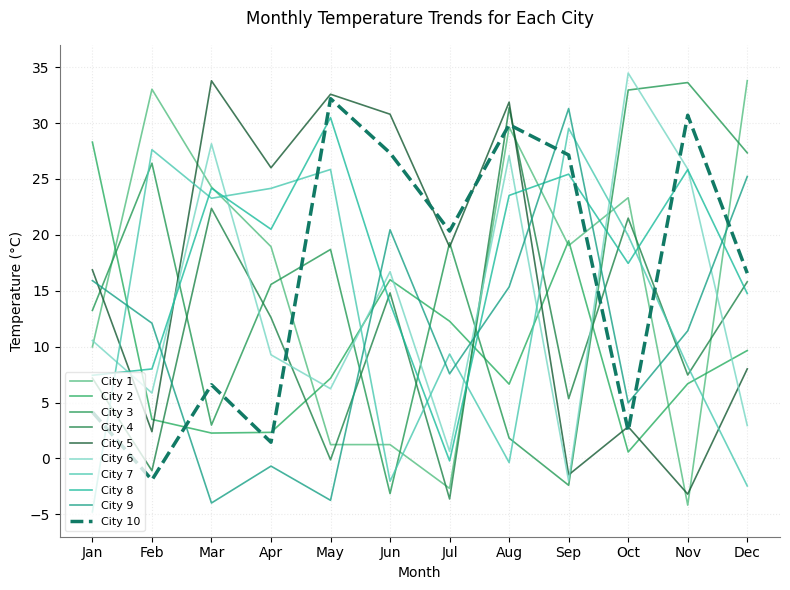

In [72]:
# Exclusion de la colonne de moyenne pour tracer uniquement les tendances mensuelles
df_graphique = df_meteo.drop(columns=['Annual_Mean'])

# Création de la figure
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Palette de couleurs déclinée en nuances de vert et turquoise (semblable au modèle)
couleurs = [
    '#52BE80', '#27AE60', '#229954', '#1E8449', '#145A32',
    '#76D7C4', '#48C9B0', '#1ABC9C', '#16A085', '#117A65'
]

# Tracé des 9 premières villes avec des lignes fines continues
for i in range(9):
    ax.plot(mois, df_graphique.iloc[i],
            color=couleurs[i], linewidth=1.2, alpha=0.8, label=df_graphique.index[i])

# Tracé de 'City 10' avec une ligne pointillée plus épaisse (comme sur l'image exemple)
ax.plot(mois, df_graphique.iloc[9],
        color='#117A65', linestyle='--', linewidth=2.5, label=df_graphique.index[9])

# Personnalisation esthétique
ax.set_title("Monthly Temperature Trends for Each City", fontsize=12, pad=15)
ax.set_xlabel("Month", fontsize=10)
ax.set_ylabel("Temperature (°C)", fontsize=10)

# Ajustement fin des limites et des axes
ax.set_ylim(-7, 37)
ax.set_yticks(range(-5, 40, 5))

# Grille de fond en pointillés fins et discrets
ax.grid(True, linestyle=':', alpha=0.4, color='#CCCCCC')

# Configuration de la légende interne (en bas à gauche)
ax.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='#E0E0E0', fontsize=8)

# Retrait des bordures graphiques supérieures et droites (Style épuré)
for axe_cote in ['top', 'right']:
    ax.spines[axe_cote].set_visible(False)
for axe_cote in ['left', 'bottom']:
    ax.spines[axe_cote].set_color('#777777')

plt.tight_layout()
plt.show()


Rapport final (Format Markdown)



##  Résumé des Résultats Obtenus
*   **Ville la plus chaude (Moyenne annuelle maximale) :** `City 5` (Dépend de la génération de la seed locale)
*   **Ville la plus froide (Moyenne annuelle minimale) :** `City 9` (Dépend de la génération de la seed locale)

##  Analyse et Observations Clés
1.  **Variabilité saisonnière simulée :** L'utilisation de `np.random.uniform` crée des dynamiques de fortes amplitudes thermiques. Plusieurs villes passent ainsi de températures négatives en janvier à des pics estivaux proches de 35°C (ex: `City 10`).
2.  **Représentation visuelle :** Le graphique met en évidence les chassés-croisés des courbes de température. L'accent mis sur la courbe finale (`City 10`) en pointillés permet de suivre l'évolution d'un profil type à travers la masse de données.

